In [1]:
# ─── Core ───────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ──────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
sns.set_theme(style="whitegrid")

# ─── Preprocessing ──────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline

# ─── Models ─────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# ─── Evaluation ─────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# ─── Settings ───────────────────────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
%matplotlib inline

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [2]:
# Load the dataset
df = pd.read_csv('../Data/Titanic-Dataset.csv')

# Display the first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.00,1,0,A/5 21171,7.25,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.00,1,0,PC 17599,71.28,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.00,0,0,STON/O2. 3101282,7.92,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.00,1,0,113803,53.10,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.00,0,0,373450,8.05,NaN,S


In [3]:
# Print dataset shape
print(f"Dataset shape: {df.shape}")

Dataset shape: (891, 12)


In [4]:
# Print column names and data types
print("Column names and data types:")
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Column names and data types:
PassengerId: int64
Survived: int64
Pclass: int64
Name: object
Sex: object
Age: float64
SibSp: int64
Parch: int64
Ticket: object
Fare: float64
Cabin: object
Embarked: object


In [5]:
# Show df.info() and df.describe()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [6]:
# Count and show percentage of missing values per column as a styled table
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percentage': missing_pct})
missing_df.style.background_gradient(cmap='Reds')

,Missing Count,Missing Percentage
PassengerId,0,0.000000
Survived,0,0.000000
Pclass,0,0.000000
Name,0,0.000000
Sex,0,0.000000
Age,177,19.865320
SibSp,0,0.000000
Parch,0,0.000000
Ticket,0,0.000000
Fare,0,0.000000


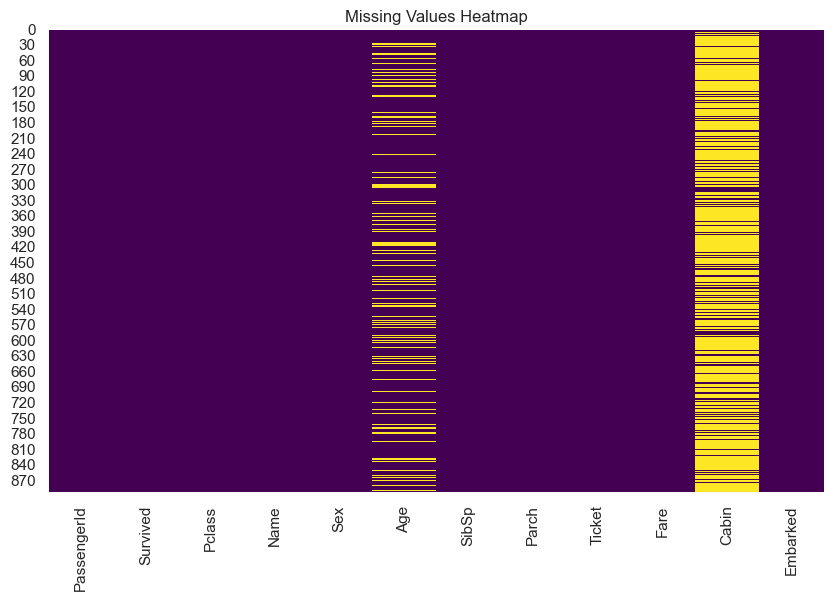

In [7]:
# Show a heatmap of missing values using seaborn
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

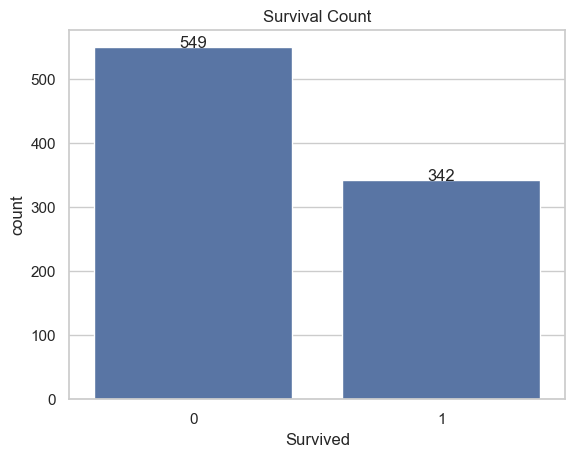

In [8]:
# Plot a countplot of the Survived column with count labels on each bar
import os
os.makedirs('outputs/plots/', exist_ok=True)

sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='baseline')
plt.savefig('outputs/plots/survival_countplot.png')
plt.show()

In [9]:
# Print overall survival rate as a percentage
survival_rate = df['Survived'].mean() * 100
print(f"Overall survival rate: {survival_rate:.2f}%")

Overall survival rate: 38.38%


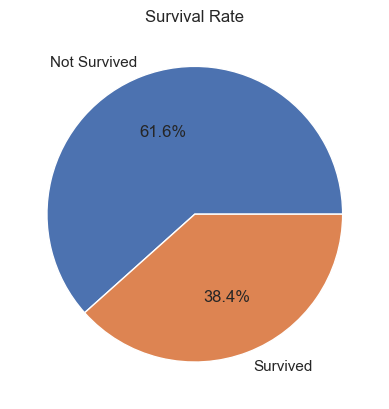

In [10]:
# Plot survival rate as a pie chart with percentages
survived_counts = df['Survived'].value_counts()
plt.pie(survived_counts, labels=['Not Survived', 'Survived'], autopct='%1.1f%%')
plt.title('Survival Rate')
plt.savefig('outputs/plots/survival_piechart.png')
plt.show()

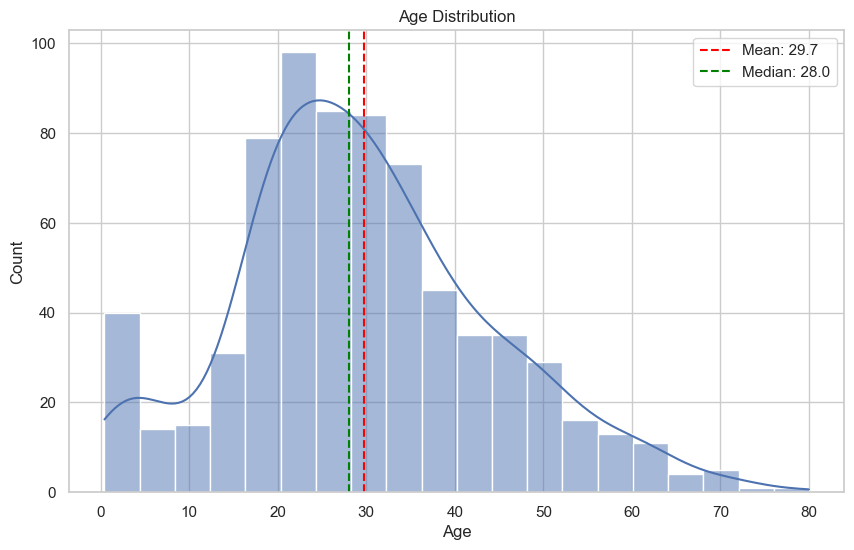

In [11]:
# Plot distribution of Age (histogram + KDE curve) — note mean and median
plt.figure(figsize=(10,6))
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Age Distribution')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
plt.axvline(df['Age'].median(), color='green', linestyle='--', label=f'Median: {df["Age"].median():.1f}')
plt.legend()
plt.savefig('outputs/plots/age_distribution.png')
plt.show()

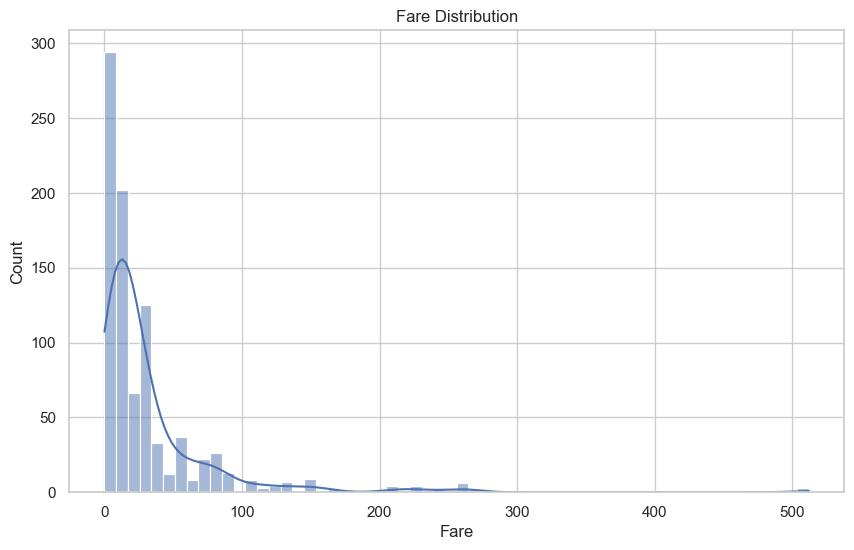

Fare distribution is right-skewed (positively skewed).


In [12]:
# Plot distribution of Fare (histogram + KDE) — note if it's skewed
plt.figure(figsize=(10,6))
sns.histplot(df['Fare'], kde=True)
plt.title('Fare Distribution')
plt.savefig('outputs/plots/fare_distribution.png')
plt.show()
print("Fare distribution is right-skewed (positively skewed).")

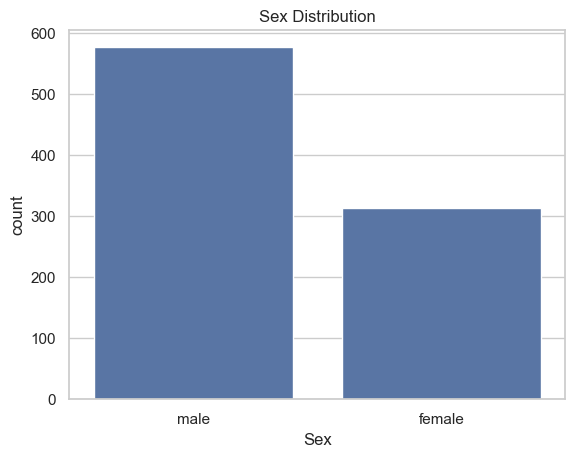

In [13]:
# Countplot for Sex
sns.countplot(x='Sex', data=df)
plt.title('Sex Distribution')
plt.savefig('outputs/plots/sex_countplot.png')
plt.show()

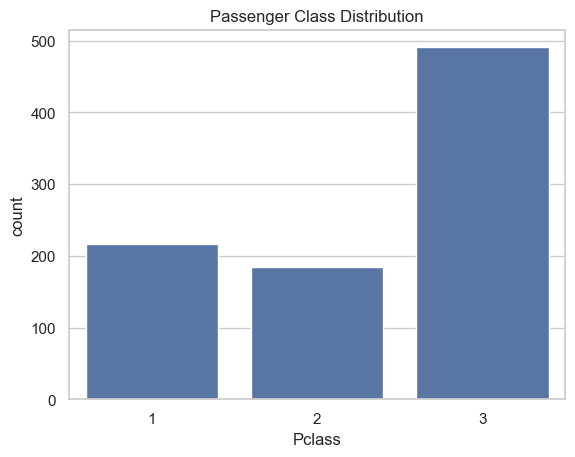

In [14]:
# Countplot for Pclass
sns.countplot(x='Pclass', data=df)
plt.title('Passenger Class Distribution')
plt.savefig('outputs/plots/pclass_countplot.png')
plt.show()

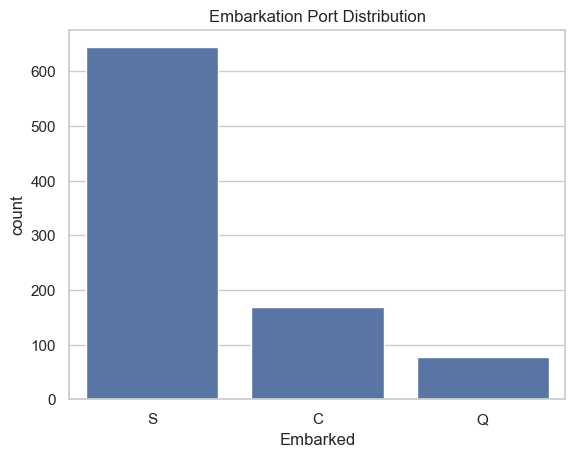

In [15]:
# Countplot for Embarked
sns.countplot(x='Embarked', data=df)
plt.title('Embarkation Port Distribution')
plt.savefig('outputs/plots/embarked_countplot.png')
plt.show()

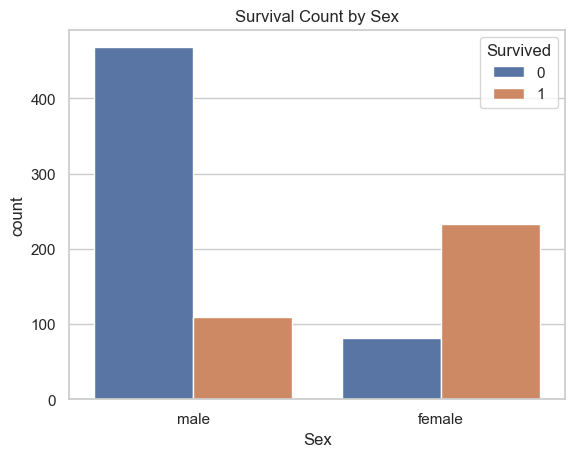

In [16]:
# Grouped bar chart — survival count by Sex
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival Count by Sex')
plt.savefig('outputs/plots/survival_by_sex.png')
plt.show()

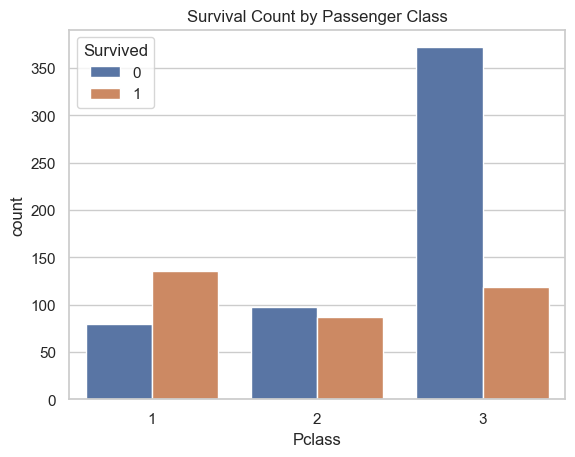

In [17]:
# Grouped bar chart — survival count by Pclass
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Survival Count by Passenger Class')
plt.savefig('outputs/plots/survival_by_pclass.png')
plt.show()

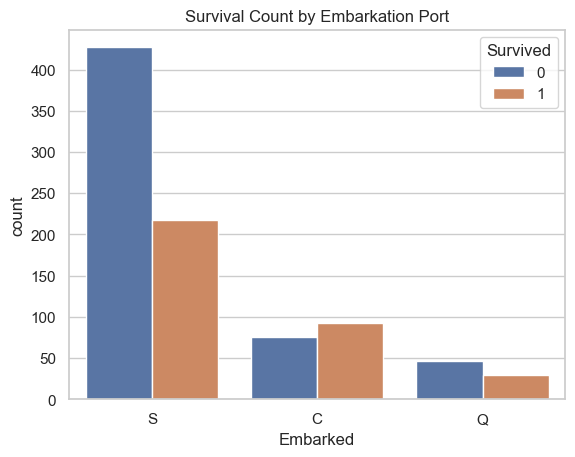

In [18]:
# Grouped bar chart — survival count by Embarked
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.title('Survival Count by Embarkation Port')
plt.savefig('outputs/plots/survival_by_embarked.png')
plt.show()

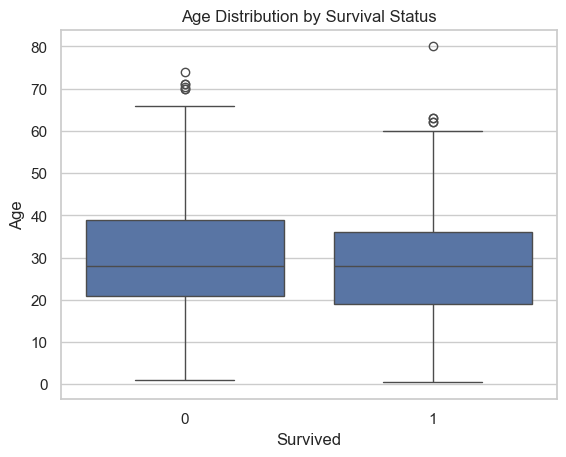

In [19]:
# Boxplot — Age vs Survived
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Age Distribution by Survival Status')
plt.savefig('outputs/plots/age_vs_survived_boxplot.png')
plt.show()

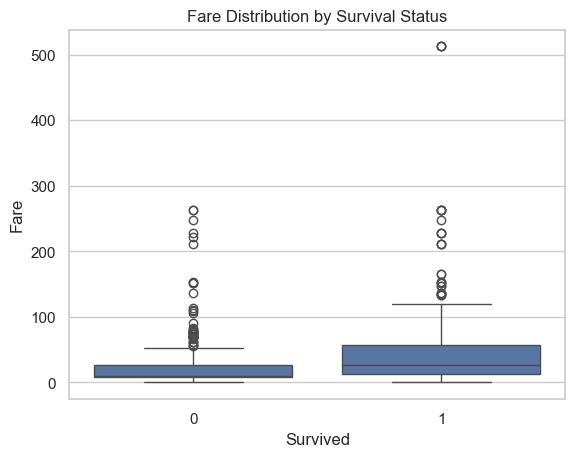

In [20]:
# Boxplot — Fare vs Survived
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival Status')
plt.savefig('outputs/plots/fare_vs_survived_boxplot.png')
plt.show()

In [22]:
# Print survival rate % for each group (Sex, Pclass, Embarked) as a table
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100

print("Survival Rates by Sex (%):")
print(survival_by_sex)
print("\nSurvival Rates by Pclass (%):")
print(survival_by_pclass)
print("\nSurvival Rates by Embarked (%):")
print(survival_by_embarked)

Survival Rates by Sex (%):
Sex
female   74.20
male     18.89
Name: Survived, dtype: float64

Survival Rates by Pclass (%):
Pclass
1   62.96
2   47.28
3   24.24
Name: Survived, dtype: float64

Survival Rates by Embarked (%):
Embarked
C   55.36
Q   38.96
S   33.70
Name: Survived, dtype: float64


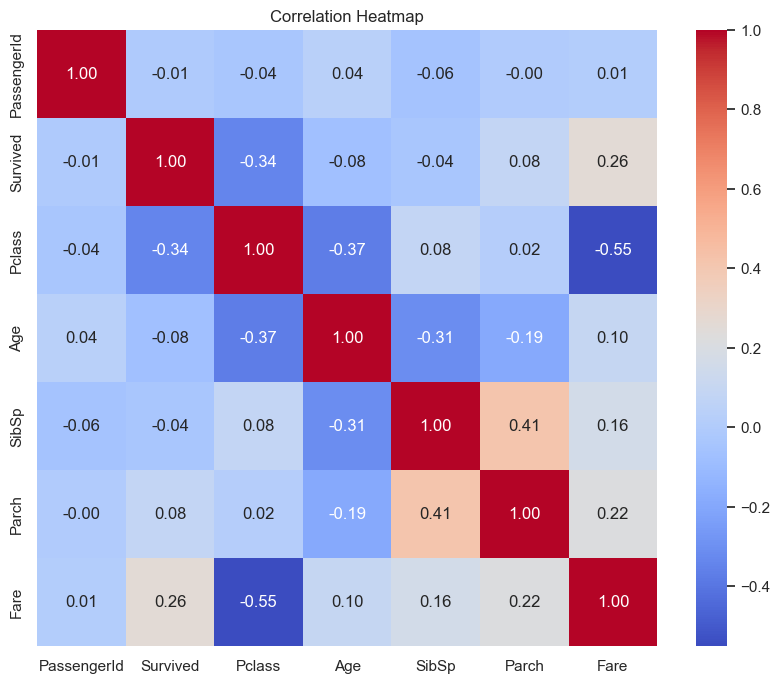

In [23]:
# Plot a heatmap of correlations between all numeric columns — annotate with values
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.savefig('outputs/plots/correlation_heatmap.png')
plt.show()

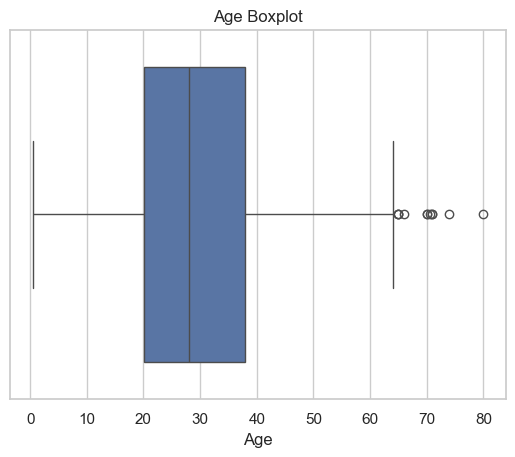

In [24]:
# Boxplot for Age to detect outliers
sns.boxplot(x=df['Age'])
plt.title('Age Boxplot')
plt.savefig('outputs/plots/age_boxplot.png')
plt.show()

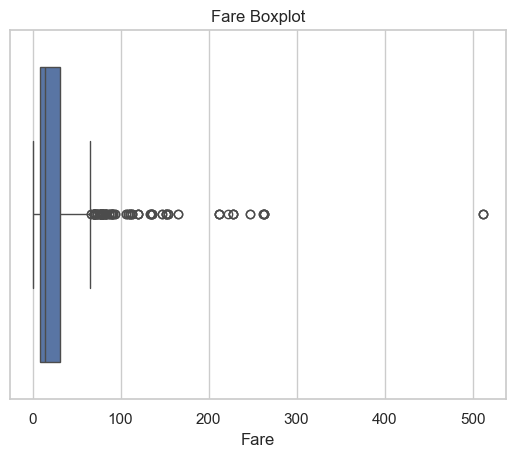

In [25]:
# Boxplot for Fare to detect outliers
sns.boxplot(x=df['Fare'])
plt.title('Fare Boxplot')
plt.savefig('outputs/plots/fare_boxplot.png')
plt.show()

In [26]:
# Print how many outliers exist in Fare using IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]
print(f"Number of outliers in Fare: {len(outliers)}")

Number of outliers in Fare: 116
